# Projeto de Ciência de Dados: Telecom Churn


Caio Santos de Almeida, caiosantal.cd@gmail.com<br>
São Paulo - SP <br>
https://www.linkedin.com/in/caiosantal <br>

<hr>

## **1 - Formulação do problema e leitura dos dados**

O objetivo deste projeto é identificar antecipadamente os clientes com maior risco de cancelamento para permitir ações de retenção. Para isso, utilizaremos uma base de dados da IBM que rastreia a rotatividade de clientes de uma empresa fictícia de telecomunicações a partir de fatores demográficos, serviços contratados e informações financeiras.

<img src="https://insidetelecom.com/wp-content/uploads/2020/11/Telecom-operators-and-reducing-customer-churn-1024x576.jpg" width="600" style="display: block; margin: 0 auto; border-radius: 0px;">

**As variáveis são:**

01. **`customerID`**: Um ID exclusivo que identifica cada cliente.
02. **`gender`**: O gênero do cliente: Masculino, Feminino.
03. **`SeniorCitizen`**: Indica se o cliente tem 65 anos ou mais: Sim, Não.
04. **`Partner`**: Indica se o cliente possui parceiro(a): Sim, Não.
05. **`Dependents`**: Indica se o cliente mora com algum dependente: Sim, Não.Dependentes podem ser filhos, pais, avós, etc.
06. **`tenure`**: Indica a quantidade total de meses que o cliente esteve na empresa até o final do trimestre especificado acima.
07. **`PhoneService`**: Indica se o cliente assina o serviço de telefonia fixa da empresa: Sim, Não.
08. **`Multiplelines`**: Indica se o cliente assina múltiplas linhas telefônicas com a empresa: Sim, Não.
09. **`InternetService`**: Indica se o cliente assina serviço de Internet com a empresa: Não, DSL, Fibra Óptica, Cabo.
10. **`OnlineSecurity`**: Indica se o cliente assina um serviço adicional de segurança online oferecido pela empresa: Sim, Não.
11. **`OnlineBackup`**: Indica se o cliente assina um serviço adicional de backup online oferecido pela empresa: Sim, Não.
12. **`DeviceProtection`**: Indica se o cliente assina um plano adicional de proteção de dispositivo para seus equipamentos de Internet oferecido pela empresa: Sim, Não.
13. **`TechSupport`**: Indica se o cliente assina um plano adicional de suporte técnico da empresa com tempos de espera reduzidos: Sim, Não.
14. **`StreamingTV`**: Indica se o cliente usa seu serviço de Internet para transmitir programação de TV de um provedor terceirizado: Sim, Não. A empresa não cobra taxa adicional por este serviço.
15. **`StreamingMovies`**: Indica se o cliente usa seu serviço de Internet para transmitir filmes de um provedor terceirizado: Sim, Não. A empresa não cobra taxa adicional por este serviço.
16. **`Contract`**: Indica o tipo de contrato atual do cliente: Mensal, Um Ano, Dois Anos.
17. **`PaperlessBilling`**: Indica se o cliente optou pela fatura digital (sem papel): Sim, Não.
18. **`PaymentMethod`**: Indica como o cliente paga sua fatura: Débito em Conta, Cartão de Crédito, Cheque via Correio.
19. **`MonthlyCharges`**: Indica a cobrança mensal total atual do cliente por todos os seus serviços com a empresa.
20. **`TotalCharges`**: Indica as cobranças totais do cliente, calculadas até o final do trimestre especificado acima.
21. **`Churn`**: Yes = o cliente cancelou o serviço neste trimestre. No = o cliente permaneceu na empresa.






Fazendo a leitura dos dados e importação das bibliotecas:

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

random.seed(42) # definindo a seed
np.random.seed(10)

drive.mount('/content/drive/')
db_bruto = pd.read_csv('/content/drive/My Drive/dados//telecom_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv', header=(0))

print("Número de linhas e colunas no conjunto de treinamento:", db_bruto.shape)

db_bruto.head(10) # Pega apenas os 10 primeiros resultados do banco de dados

Mounted at /content/drive/
Número de linhas e colunas no conjunto de treinamento: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Nota da Etapa: O dataset contém 7.043 registros de clientes e 21 colunas originais, combinando variáveis numéricas (como tempo de casa `tenure` e cobrança mensal `MonthlyCharges`) e categóricas.

## **2 - Limpeza e normalização dos dados**

Nesta etapa, preparamos a base para os algoritmos de aprendizado de máquina:

1. Removemos identificadores únicos que não agregam valor preditivo (`customerID`).
2. Removemos colunas redundantes ou com alto risco de vazamento de dados (`gender` e `TotalCharges`).
3. Convertemos variáveis categóricas (textuais) em numéricas binárias via One-Hot Encoding (`pd.get_dummies`).

In [4]:
db = db_bruto.drop(columns=['customerID','gender', 'TotalCharges'])
print("Número de linhas e colunas no conjunto de treinamento:", db.shape)
db.head(10)

Número de linhas e colunas no conjunto de treinamento: (7043, 18)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes
5,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,Yes
6,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,No
7,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,No
8,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,Yes
9,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,No


In [5]:
db.isnull().sum().sort_values(ascending=False).head(10)

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [6]:
db_pre_encoding = db
db = pd.get_dummies(db, drop_first=True, dtype=int)
db.head(10)

,SeniorCitizen,tenure,MonthlyCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,1,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,0,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1
5,0,8,99.65,0,0,1,0,1,1,0,...,1,0,1,0,0,1,0,1,0,1
6,0,22,89.10,0,1,1,0,1,1,0,...,1,0,0,0,0,1,1,0,0,0
7,0,10,29.75,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,0,28,104.80,1,0,1,0,1,1,0,...,1,0,1,0,0,1,0,1,0,1
9,0,62,56.15,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


Nota da Etapa: A transformação expandiu o conjunto para 29 colunas numéricas (0 ou 1), mantendo a variável alvo `Churn_Yes` devidamente tratada.

## **3 - Divisão dos Dados (Treino e Teste)**

Separamos os dados em $X$ (atributos de entrada) e $y$ (variável alvo `Churn_Yes`). Em seguida, dividimos a base em 80% para treinamento e 20% para teste, utilizando o parâmetro `stratify=y` para manter a proporção da classe de cancelamento igual em ambas as bases.

In [7]:
from sklearn.model_selection import train_test_split

# 1. Separar Variáveis de Entrada (X) e a Variável Alvo (y)
# 'Churn_Yes' é o nome da sua coluna alvo criada pelo get_dummies
X = db.drop(columns=['Churn_Yes'])
y = db['Churn_Yes']

# 2. Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20,       # 20% dos dados para teste
    random_state=42,      # Garante que os resultados sejam reprodutíveis
    stratify=y            # Mantém a mesma proporção de Churn no treino e no teste!
)

# 3. Conferindo o tamanho das bases geradas
print("Tamanho do X_train (Treino):", X_train.shape)
print("Tamanho do X_test (Teste):", X_test.shape)
print("\nProporção de Churn no Treino:\n", y_train.value_counts(normalize=True))
print("\nProporção de Churn no Teste:\n", y_test.value_counts(normalize=True))

Tamanho do X_train (Treino): (5634, 28)
Tamanho do X_test (Teste): (1409, 28)

Proporção de Churn no Treino:
 Churn_Yes
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporção de Churn no Teste:
 Churn_Yes
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Nota da Etapa: A proporção de cancelamentos foi mantida em ~26.5% no treino e no teste, garantindo uma avaliação não viesada.

## **4 - Normalização (Escalonamento)**

Modelos lineares como a Regressão Logística são sensíveis à escala dos dados. Aplicamos o `StandardScaler` exclusivamente nas colunas numéricas contínuas (`tenure` e `MonthlyCharges`).

O ajuste (fit) é feito estritamente na base de treino para evitar vazamento de informações do teste (data leakage).

In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Instanciar o escalonador
scaler = StandardScaler()

# 2. Copiar os DataFrames para evitar sobrescrever a base original
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 3. Listar apenas as colunas numéricas contínuas para escalonar
colunas_numericas = ['tenure', 'MonthlyCharges']

# 4. Ajustar no Treino e transformar Treino e Teste
X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

# Conferir o resultado
X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
3151,0,-0.711743,0.337478,1,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,-0.793155,-0.809013,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
3867,0,-0.263980,0.284384,1,0,1,0,0,0,0,...,0,1,0,1,0,1,1,1,0,0
3810,0,-1.281624,-0.676279,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


Nota da Etapa: As variáveis contínuas agora possuem média 0 e desvio padrão 1, mantendo as colunas binárias (*dummies*) intactas.

## **5 - Análise Descritiva e Correlação**

### **5.1 - Distribuição das Variáveis Numéricas**

Analisamos visualmente a distribuição do tempo de permanência dos clientes (`tenure`) e o valor das cobranças mensais (`MonthlyCharges`) para identificar concentração de perfis e padrões de consumo na base de treino.

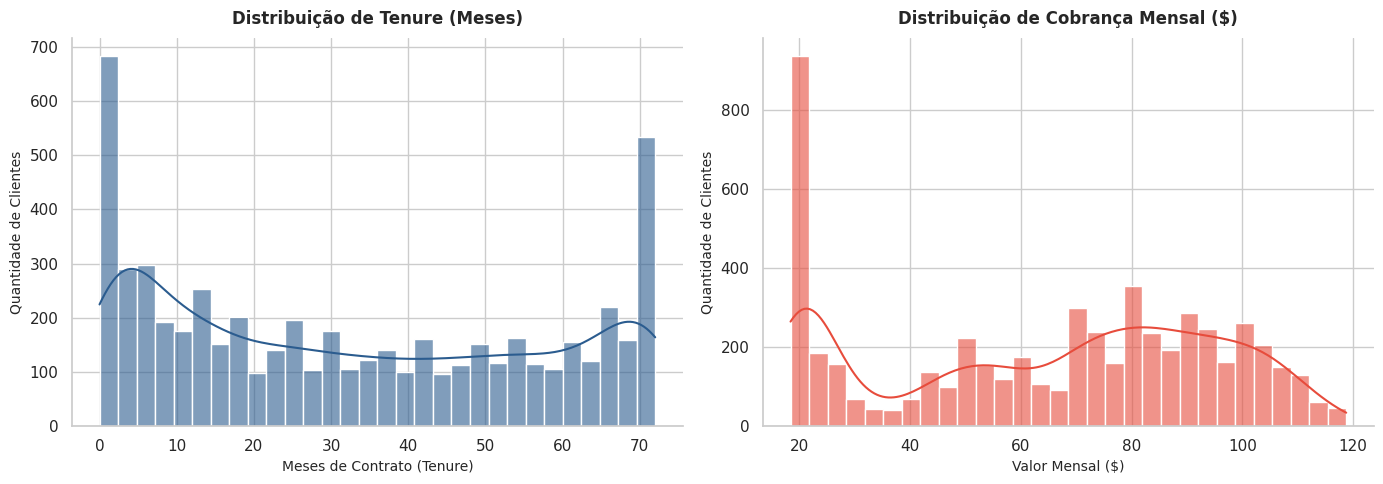

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aplicando um estilo visual mais limpo e elegante
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma do Tempo de Permanência (tenure)
sns.histplot(X_train['tenure'], kde=True, ax=axes[0], color='#2b5c8f', bins=30, alpha=0.6)
axes[0].set_title('Distribuição de Tenure (Meses)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Meses de Contrato (Tenure)', fontsize=10)
axes[0].set_ylabel('Quantidade de Clientes', fontsize=10)

# 2. Histograma das Cobranças Mensais (MonthlyCharges)
sns.histplot(X_train['MonthlyCharges'], kde=True, ax=axes[1], color='#e74c3c', bins=30, alpha=0.6)
axes[1].set_title('Distribuição de Cobrança Mensal ($)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Valor Mensal ($)', fontsize=10)
axes[1].set_ylabel('Quantidade de Clientes', fontsize=10)

# Ajuste visual de bordas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### **5.2 - Correlação de Pearson com a Variável Alvo (`Churn_Yes`)**

In [29]:
# Unindo temporariamente X e y de treino para o cálculo
df_treino = X_train.copy()
df_treino['Churn_Yes'] = y_train

# Cálculo do coeficiente de correlação de Pearson com a variável alvo
correlacoes = df_treino.corr()['Churn_Yes'].drop('Churn_Yes').sort_values(ascending=False)

# Exibindo os valores em linhas formatadas
print("--- Correlação de Pearson com Churn_Yes ---")
for atributo, valor in correlacoes.items():
    print(f"{atributo:<40}: {valor:.4f}")

--- Correlação de Pearson com Churn_Yes ---
InternetService_Fiber optic             : 0.3127
PaymentMethod_Electronic check          : 0.3092
MonthlyCharges                          : 0.1980
PaperlessBilling_Yes                    : 0.1980
SeniorCitizen                           : 0.1456
StreamingTV_Yes                         : 0.0724
StreamingMovies_Yes                     : 0.0638
MultipleLines_Yes                       : 0.0438
PhoneService_Yes                        : 0.0179
MultipleLines_No phone service          : -0.0179
DeviceProtection_Yes                    : -0.0616
OnlineBackup_Yes                        : -0.0824
PaymentMethod_Mailed check              : -0.0893
PaymentMethod_Credit card (automatic)   : -0.1378
Partner_Yes                             : -0.1457
TechSupport_Yes                         : -0.1657
Dependents_Yes                          : -0.1675
OnlineSecurity_Yes                      : -0.1746
Contract_One year                       : -0.1795
InternetService

Calculamos o coeficiente de correlação de Pearson de todas as variáveis explicativas com a variável `Churn_Yes`. O gráfico destaca os atributos em vermelho para o aumento do risco de cancelamento e em azul para a retenção do cliente.

/tmp/ipykernel_582/1613956220.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacoes.values, y=correlacoes.index, palette=colors)


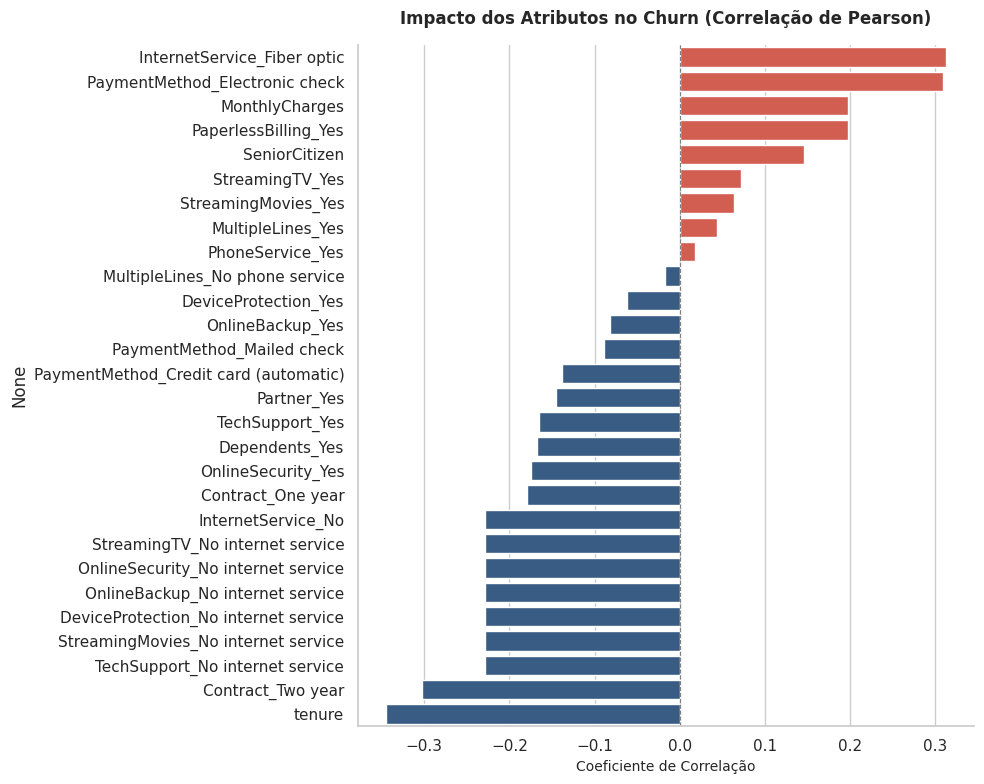

In [28]:
# Unindo temporariamente X e y de treino para o cálculo
df_treino = X_train.copy()
df_treino['Churn_Yes'] = y_train

# Cálculo do coeficiente de correlação com a variável alvo
correlacoes = df_treino.corr()['Churn_Yes'].drop('Churn_Yes').sort_values(ascending=False)

# Plotagem do gráfico de barras horizontal estilizado (Vermelho = Churn, Azul = Retenção)
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if val > 0 else '#2b5c8f' for val in correlacoes.values]

sns.barplot(x=correlacoes.values, y=correlacoes.index, palette=colors)
plt.title('Impacto dos Atributos no Churn (Correlação de Pearson)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Coeficiente de Correlação', fontsize=10)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### **5.3 - Matriz de Correlação Cruzada (Heatmap)**

Utilizamos o mapa de calor com a matriz de correlação cruzada entre os principais atributos numéricos e a variável alvo, permitindo identificar possíveis problemas de multicolinearidade.

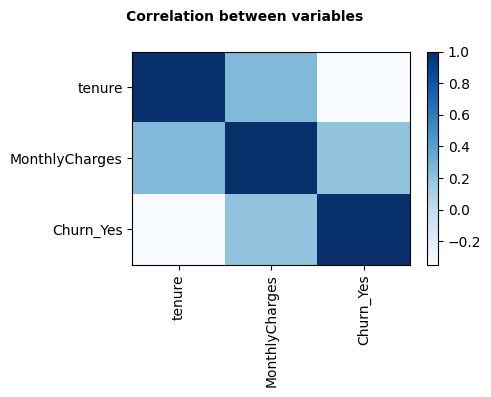

In [22]:
# Calcular a matriz de correlação dos dados de treino
corr = df_treino[['tenure', 'MonthlyCharges', 'Churn_Yes']].corr()

# Plotar a Matriz de Correlação usando Matplotlib (Estilo Titanic)
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap='Blues', interpolation='none', aspect='auto')
plt.colorbar()

# Configuração dos eixos e rótulos
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns)
plt.suptitle('Correlation between variables', fontsize=10, fontweight='bold')
plt.grid(False)

plt.tight_layout()
plt.show()

Nota da Etapa:

1. **Distribuição:** A análise das distribuições revela uma grande concentração de clientes nos primeiros meses de contrato (`tenure`), indicando que o início da jornada é o período mais crítico para o cancelamento.
2. **Correlação com o Churn:** Contratos mensais (`Month-to-month`), pagamento com cheque eletrônico e serviços de internet via fibra óptica são os fatores que mais aumentam a probabilidade de *Churn*. Em contrapartida, contratos de longo prazo (1 ou 2 anos) e maior tempo de casa atua como fortes retentores.
3. **Multicolinearidade:** O mapa de calor confirma que não há colinearidade extrema que comprometa os coeficientes da Regressão Logística.

## **6 - Modelagem e Avaliação**

Nesta etapa, treinamos e avaliamos diferentes abordagens de classificação para prever o cancelamento de clientes. Como a base de dados possui desbalanceamento (mais clientes mantidos do que cancelados), avaliamos os modelos não apenas pela Acurácia, mas principalmente pelo ROC AUC Score e pelo Recall da classe 1 (Churn), garantindo que o modelo capture o maior número de clientes em risco.

### **6.1 - Regressão Logística (Modelo Baseline)**

Treinamos um modelo de Regressão Logística com as configurações padrão (limiar de 0.50 e sem ajuste de pesos) para servir como ponto de partida (baseline).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# 1. Instanciar e Treinar o Modelo
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# 2. Fazer Previsões na Base de Teste
y_pred = modelo_lr.predict(X_test_scaled)
y_pred_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1] # Probabilidades de ser Churn (1)

# 3. Avaliar os Resultados
print("--- Métricas de Avaliação ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))

--- Métricas de Avaliação ---
Acurácia: 0.7977
ROC AUC Score: 0.8395

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

--- Matriz de Confusão ---
[[918 117]
 [168 206]]


Nota do Modelo Baseline: Embora a acurácia seja alta (~80%) e o ROC AUC seja sólido (0.8395), o modelo capturou apenas 55% dos cancelamentos reais (206 de 374 clientes), deixando passar 168 clientes em risco devido ao limiar padrão e ao desbalanceamento da base.

### **6.2 - Regressão Logística com Pesos Balanceados**

Para compensar o desbalanceamento das classes, aplicamos a penalização class_weight='balanced'. Isso força o algoritmo a atribuir maior peso aos erros cometidos na classe de cancelamento.

In [15]:
# 1. Regressão Logística com pesos balanceados
modelo_lr_balanced = LogisticRegression(random_state=42, class_weight='balanced')
modelo_lr_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = modelo_lr_balanced.predict(X_test_scaled)
y_pred_proba_balanced = modelo_lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("--- Métricas (Com Class Weight Balanced) ---")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_balanced):.4f}\n")
print(classification_report(y_test, y_pred_balanced))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_balanced))

--- Métricas (Com Class Weight Balanced) ---
ROC AUC Score: 0.8391

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Matriz de Confusão:
[[756 279]
 [ 83 291]]


Nota do Modelo Balanceado: O Recall para a classe de Churn subiu de 55% para 78% (291 de 374 clientes identificados), tornando o modelo muito mais eficaz para estratégias preventivas de retenção.

### **6.3 - Regressão Logística com Limiar Customizado**

Em vez de utilizar o corte fixo em 50%, reduzimos o limiar de decisão para 35% nas probabilidades calculadas pelo modelo baseline. Essa técnica permite calibrar o equilíbrio entre capturar mais cancelamentos e conter o número de falsos alarmes.

In [16]:
# 2. Testando um limiar de decisão customizado (ex: 35%) na probabilidade do modelo original
limiar = 0.35
y_pred_custom = (y_pred_proba >= limiar).astype(int)

print(f"--- Relatório com Limiar de {limiar*100}% ---")
print(classification_report(y_test, y_pred_custom))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_custom))

--- Relatório com Limiar de 35.0% ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

Matriz de Confusão:
[[814 221]
 [109 265]]


Nota do Ajuste de Limiar: Com o limiar em 35%, o modelo capturou 71% dos cancelamentos (265 clientes) gerando um número significativamente menor de alarmes falsos (221 contra 279 da versão balanceada), sendo ideal para operações com orçamento de retenção mais restrito.

### **6.4 - Modelo Random Forest**

Testamos o algoritmo não linear Random Forest, capaz de capturar combinações complexas de atributos (como a relação combinada entre tipo de contrato, tempo de casa e serviços de internet).

In [17]:
from sklearn.ensemble import RandomForestClassifier

# 3. Testando o algoritmo Random Forest
modelo_rf = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=6)
modelo_rf.fit(X_train, y_train) # Árvores não precisam das variáveis escalonadas

y_pred_rf = modelo_rf.predict(X_test)
y_pred_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("--- Métricas (Random Forest) ---")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

--- Métricas (Random Forest) ---
ROC AUC Score: 0.8382

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Matriz de Confusão:
[[746 289]
 [ 77 297]]


Nota da Random Forest: O modelo obteve a maior taxa de acerto na classe de Churn (79% de Recall, 297 clientes capturados) e manteve um excelente ROC AUC (0.8385), consolidando-se como a solução de maior capacidade preditiva bruta.

## **7 - Conclusão**

Os modelos desenvolvidos — em especial a Random Forest (`balanced`) e a Regressão Logística (com limiar ajustado a 35%) — demonstraram excelente capacidade preditiva, capturando entre 71% e 79% de todos os potenciais cancelamentos de clientes (Recall).

**Principais Insights Extraídos das Correlações:**

*  Ofensores Principais (Aumentam o Churn): As variáveis com maior correlação positiva com o cancelamento são a assinatura de Internet por Fibra Óptica (`+0.3127`) e o pagamento via Cheque Eletrônico (`+0.3092`), seguidos por Cobrança Mensal elevada (`+0.1980`) e Fatura Digital (`+0.1980`).
*  Fatores de Retenção (Reduzem o Churn): O tempo de permanência (`tenure` a `-0.3456`) e os contratos de longo prazo (`Contract_Two year` a `-0.3022`) são as variáveis que mais protegem a base contra o cancelamento.

**Recomendações Práticas para a Operação:**

1. **Ações no Onboarding:** Focar os esforços de suporte e experiência do cliente nos primeiros meses de contrato (`tenure` baixo), período de maior risco de evasão.

2. **Revisão da Experiência em Fibra Óptica e Pagamentos:** Investigar os motivos de insatisfação em clientes com internet via fibra óptica e incentivar a migração do pagamento via cheque eletrônico para débito ou cartão automático (que possuem correlação negativa com o Churn).

3. **Planos de Fidelização:** Estimular a transição de contratos mensais para planos anuais ou bienais oferecendo benefícios progressivos.